# Dataset Comparison: `net_fish_sonar` vs `net_fish_sonar_improved`

This notebook compares the two sonar datasets:
- **Original**: `net_fish_sonar` — 2,000 images with YOLO annotations
- **Improved**: `net_fish_sonar_improved` — re-annotated/expanded dataset

Both datasets use 2 classes: `0 = fish`, `1 = net`.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Dataset roots
ORIG_ROOT  = '/cluster/home/henrban/aquaculture-perception/data-processing/sonar/net_fish_sonar/processed/split_yolo_fish_net'
IMPR_ROOT  = '/cluster/home/henrban/aquaculture-perception/data-processing/sonar/net_fish_sonar_improved/processed'

IMG_W, IMG_H = 1200, 700  # all images share this resolution
CLASS_NAMES  = {0: 'fish', 1: 'net'}
CLASS_COLORS = {0: '#FF4444', 1: '#44AAFF'}  # red=fish, blue=net

## 1. Split-level statistics

In [2]:
orig_summary = pd.read_csv(f'{ORIG_ROOT}/split_summary.csv')
impr_summary = pd.read_csv(f'{IMPR_ROOT}/split_summary.csv')

orig_summary.insert(0, 'dataset', 'original')
impr_summary.insert(0, 'dataset', 'improved')

# Align columns (improved CSV has fewer columns)
cols = ['dataset', 'split', 'bags', 'images', 'fish_images', 'fish_instances', 'net_instances', 'total_instances']
orig_df = orig_summary[cols]
impr_df = impr_summary[['dataset', 'split', 'bags', 'images', 'fish_images', 'fish_instances', 'net_instances']].copy()
impr_df['total_instances'] = impr_df['fish_instances'] + impr_df['net_instances']
impr_df = impr_df[cols]

combined = pd.concat([orig_df, impr_df], ignore_index=True)
combined

,dataset,split,bags,images,fish_images,fish_instances,net_instances,total_instances
0,original,train,6,1200,180,408,1200,1608
1,original,val,2,400,58,141,400,541
2,original,test,2,400,70,144,400,544
3,improved,train,6,1336,418,637,1336,1973
4,improved,val,2,400,58,141,400,541
5,improved,test,2,400,70,144,400,544


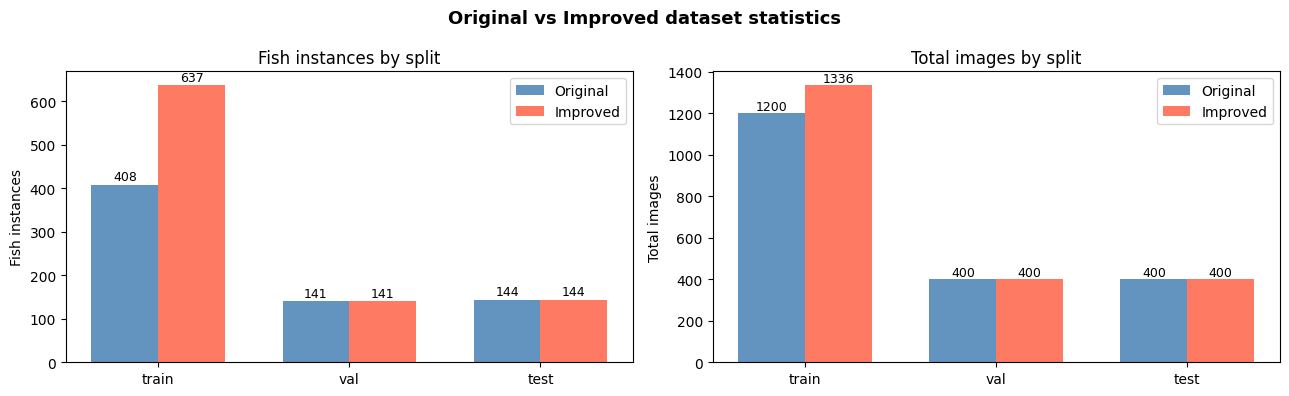

In [3]:
# Bar chart: fish instances per split for each dataset
splits = ['train', 'val', 'test']
x = np.arange(len(splits))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, ylabel in zip(
    axes,
    ['fish_instances', 'images'],
    ['Fish instances', 'Total images']
):
    orig_vals = [combined[(combined['dataset']=='original') & (combined['split']==s)][metric].values[0] for s in splits]
    impr_vals = [combined[(combined['dataset']=='improved') & (combined['split']==s)][metric].values[0] for s in splits]

    b1 = ax.bar(x - w/2, orig_vals, w, label='Original', color='steelblue', alpha=0.85)
    b2 = ax.bar(x + w/2, impr_vals, w, label='Improved', color='tomato',   alpha=0.85)

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + ' by split')
    ax.legend()

plt.suptitle('Original vs Improved dataset statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. What changed? — annotation-level diff

Key findings from counting the actual label files (the summary CSVs in the improved dataset are stale):

| Split | Change |
|-------|--------|
| **Train** | +136 images (1,200 → 1,336); **+229 fish instances** (408 → 637); net kept 1:1 |
| **Val** | Identical (400 imgs, 141 fish, 400 net) |
| **Test** | Same 400 images; **+21 fish instances** (144 → 165) across 17 images; fish BBs also re-annotated |

In [4]:
def load_labels(label_dir):
    """Return dict: filename -> list of (class_id, cx, cy, w, h)"""
    result = {}
    for path in glob.glob(os.path.join(label_dir, '*.txt')):
        fname = os.path.basename(path)
        boxes = []
        with open(path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    boxes.append((int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])))
        result[fname] = boxes
    return result

orig_test_labels = load_labels(f'{ORIG_ROOT}/labels/test')
impr_test_labels = load_labels(f'{IMPR_ROOT}/labels/test')

print(f'Original test label files: {len(orig_test_labels)}')
print(f'Improved test label files: {len(impr_test_labels)}')

Original test label files: 400
Improved test label files: 400


In [5]:
# Compute per-image fish count diff and per-fish BB area changes for the test set
common_files = set(orig_test_labels.keys()) & set(impr_test_labels.keys())

count_records = []
bb_records = []

for fname in sorted(common_files):
    orig_fish = [(cx, cy, w, h) for cls, cx, cy, w, h in orig_test_labels[fname] if cls == 0]
    impr_fish = [(cx, cy, w, h) for cls, cx, cy, w, h in impr_test_labels[fname] if cls == 0]

    count_records.append({
        'file': fname,
        'orig_fish': len(orig_fish),
        'impr_fish': len(impr_fish),
        'fish_gained': len(impr_fish) - len(orig_fish),
    })

    # Only compare matched pairs (min count) for BB-area analysis
    for i, (o, m) in enumerate(zip(orig_fish, impr_fish)):
        o_area = o[2] * o[3]
        m_area = m[2] * m[3]
        bb_records.append({
            'file': fname,
            'fish_idx': i,
            'orig_cx': o[0], 'orig_cy': o[1], 'orig_w': o[2], 'orig_h': o[3],
            'impr_cx': m[0], 'impr_cy': m[1], 'impr_w': m[2], 'impr_h': m[3],
            'orig_area': o_area,
            'impr_area': m_area,
            'area_diff_rel': abs(o_area - m_area) / max(o_area, 1e-9),
        })

df_counts = pd.DataFrame(count_records)
df_diff   = pd.DataFrame(bb_records)

images_gained = df_counts[df_counts['fish_gained'] > 0]
print(f'Test images that gained fish in improved: {len(images_gained)}')
print(f'Total new fish instances added to test:   {images_gained["fish_gained"].sum()}')
print()
print(images_gained[['file', 'orig_fish', 'impr_fish', 'fish_gained']]
      .sort_values('fish_gained', ascending=False).to_string(index=False))
print()
print(f'--- BB area shift (matched pairs only) ---')
print(f'Median relative area change: {df_diff["area_diff_rel"].median():.3f}')
print(f'Mean   relative area change: {df_diff["area_diff_rel"].mean():.3f}')
print(f'BBs with >10% area change:   {(df_diff["area_diff_rel"] > 0.1).sum()}')
print(f'BBs with >30% area change:   {(df_diff["area_diff_rel"] > 0.3).sum()}')

Test images that gained fish in improved: 17
Total new fish instances added to test:   22

                        file  orig_fish  impr_fish  fish_gained
bag1_1724155098327484700.txt          4          7            3
bag1_1724155097943271100.txt          3          5            2
bag1_1724155096340093500.txt          2          4            2
bag1_1724155100314989500.txt          2          4            2
bag1_1724155095512786400.txt          3          4            1
bag1_1724155097116416500.txt          3          4            1
bag1_1724155096725122000.txt          3          4            1
bag1_1724155098708715500.txt          3          4            1
bag1_1724155095897127800.txt          3          4            1
bag1_1724155099545357500.txt          3          4            1
bag1_1724155100758227300.txt          2          3            1
bag1_1724155101140157600.txt          1          2            1
bag9_1724165299803897300.txt          4          5            1
bag9_17241653

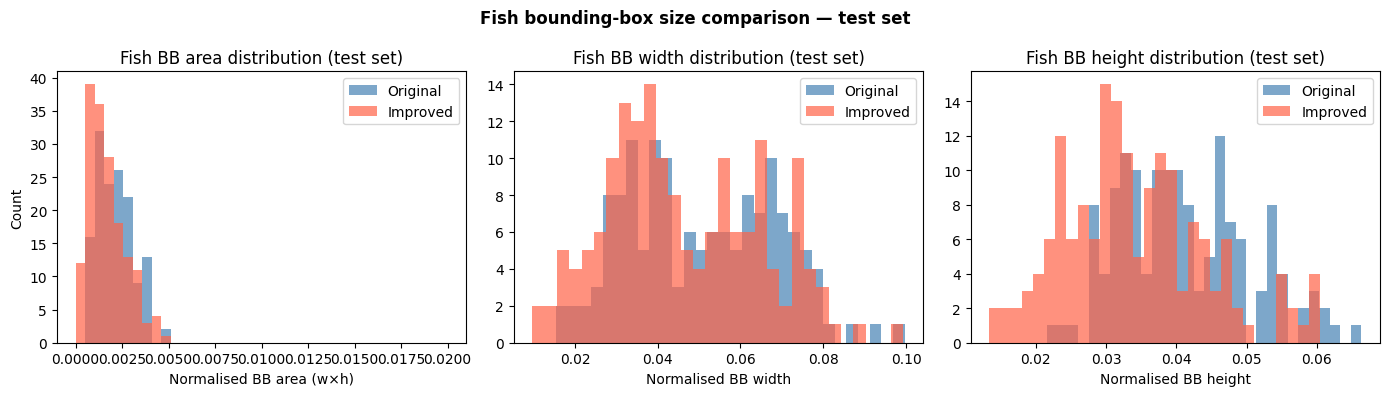


Fish BB area  — original: mean=0.00213  improved: mean=0.00168
Fish BB width — original: mean=0.0508     improved: mean=0.0461
Fish BB height— original: mean=0.0411     improved: mean=0.0341


In [6]:
# Distribution of fish BB area in original vs improved (test set)
orig_all = []
impr_all = []
for fname in common_files:
    for cls, cx, cy, w, h in orig_test_labels[fname]:
        if cls == 0:
            orig_all.append(w * h)
    for cls, cx, cy, w, h in impr_test_labels[fname]:
        if cls == 0:
            impr_all.append(w * h)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

bins = np.linspace(0, 0.02, 40)
axes[0].hist(orig_all, bins=bins, alpha=0.7, label='Original', color='steelblue')
axes[0].hist(impr_all, bins=bins, alpha=0.7, label='Improved', color='tomato')
axes[0].set_xlabel('Normalised BB area (w×h)')
axes[0].set_ylabel('Count')
axes[0].set_title('Fish BB area distribution (test set)')
axes[0].legend()

# Width distribution
orig_w = [w for fname in common_files for cls,cx,cy,w,h in orig_test_labels[fname] if cls==0]
impr_w = [w for fname in common_files for cls,cx,cy,w,h in impr_test_labels[fname] if cls==0]
axes[1].hist(orig_w, bins=30, alpha=0.7, label='Original', color='steelblue')
axes[1].hist(impr_w, bins=30, alpha=0.7, label='Improved', color='tomato')
axes[1].set_xlabel('Normalised BB width')
axes[1].set_title('Fish BB width distribution (test set)')
axes[1].legend()

# Height distribution
orig_h = [h for fname in common_files for cls,cx,cy,w,h in orig_test_labels[fname] if cls==0]
impr_h = [h for fname in common_files for cls,cx,cy,w,h in impr_test_labels[fname] if cls==0]
axes[2].hist(orig_h, bins=30, alpha=0.7, label='Original', color='steelblue')
axes[2].hist(impr_h, bins=30, alpha=0.7, label='Improved', color='tomato')
axes[2].set_xlabel('Normalised BB height')
axes[2].set_title('Fish BB height distribution (test set)')
axes[2].legend()

plt.suptitle('Fish bounding-box size comparison — test set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nFish BB area  — original: mean={np.mean(orig_all):.5f}  improved: mean={np.mean(impr_all):.5f}')
print(f'Fish BB width — original: mean={np.mean(orig_w):.4f}     improved: mean={np.mean(impr_w):.4f}')
print(f'Fish BB height— original: mean={np.mean(orig_h):.4f}     improved: mean={np.mean(impr_h):.4f}')

## 3. Visual examples — how did the bounding boxes change?

Each row shows the **same image** from the test set, zoomed into the fish region.
- **Left**: original annotation — **Right**: improved annotation
- Colours: **red = fish**, **blue = net**

Examples are sorted by most fish gained first, then by largest BB area change.

In [7]:
def yolo_to_pixel(cx, cy, w, h, img_w=IMG_W, img_h=IMG_H):
    x1 = (cx - w/2) * img_w
    y1 = (cy - h/2) * img_h
    bw = w * img_w
    bh = h * img_h
    return x1, y1, bw, bh

def fish_zoom_region(orig_boxes, impr_boxes, pad_px=60, img_w=IMG_W, img_h=IMG_H):
    """Return (x1, x2, y1, y2) pixel crop that covers all fish boxes in both sets."""
    all_fish = [(cx, cy, w, h) for cls, cx, cy, w, h in orig_boxes + impr_boxes if cls == 0]
    if not all_fish:
        return 0, img_w, 0, img_h

    xs1 = [(cx - w/2) * img_w for cx, cy, w, h in all_fish]
    xs2 = [(cx + w/2) * img_w for cx, cy, w, h in all_fish]
    ys1 = [(cy - h/2) * img_h for cx, cy, w, h in all_fish]
    ys2 = [(cy + h/2) * img_h for cx, cy, w, h in all_fish]

    x1 = max(0,     min(xs1) - pad_px)
    x2 = min(img_w, max(xs2) + pad_px)
    y1 = max(0,     min(ys1) - pad_px)
    y2 = min(img_h, max(ys2) + pad_px)
    return x1, x2, y1, y2

def draw_boxes(ax, img, boxes, title, zoom=None):
    ax.imshow(img, cmap='gray')
    for cls, cx, cy, w, h in boxes:
        x1, y1, bw, bh = yolo_to_pixel(cx, cy, w, h)
        color = CLASS_COLORS[cls]
        lw = 2.5 if cls == 0 else 1.5
        rect = patches.Rectangle((x1, y1), bw, bh,
                                  linewidth=lw, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 3, CLASS_NAMES[cls], color=color,
                fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.55))
    if zoom:
        zx1, zx2, zy1, zy2 = zoom
        ax.set_xlim(zx1, zx2)
        ax.set_ylim(zy2, zy1)   # y-axis is inverted for images
    ax.set_title(title, fontsize=10)
    ax.axis('off')

def show_comparison(example_files, pad_px=70):
    n = len(example_files)
    fig, axes = plt.subplots(n, 2, figsize=(18, n * 5))
    if n == 1:
        axes = [axes]

    for row, fname in enumerate(example_files):
        img_name = fname.replace('.txt', '.jpg')
        img_path = os.path.join(ORIG_ROOT, 'images', 'test', img_name)
        if not os.path.exists(img_path):
            img_path = os.path.join(IMPR_ROOT, 'images', 'test', img_name)
        img = Image.open(img_path)

        orig_boxes = orig_test_labels.get(fname, [])
        impr_boxes = impr_test_labels.get(fname, [])

        # Shared zoom region so both panels crop identically
        zoom = fish_zoom_region(orig_boxes, impr_boxes, pad_px=pad_px)

        orig_fish_n = sum(1 for c,*_ in orig_boxes if c==0)
        impr_fish_n = sum(1 for c,*_ in impr_boxes if c==0)

        draw_boxes(axes[row][0], img, orig_boxes,
                   f'ORIGINAL  ({orig_fish_n} fish)  —  {img_name}', zoom=zoom)
        draw_boxes(axes[row][1], img, impr_boxes,
                   f'IMPROVED  ({impr_fish_n} fish)  —  {img_name}', zoom=zoom)

    plt.suptitle('Bounding box comparison: original vs improved (test set) — zoomed to fish region',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

In [8]:
# Prioritise images that gained fish, then by largest BB area change among the rest
gained_files = (
    df_counts[df_counts['fish_gained'] > 0]
    .sort_values('fish_gained', ascending=False)
    ['file'].tolist()
)

# Fill remaining slots with biggest BB-area changes (no count change)
bb_change_files = (
    df_diff[~df_diff['file'].isin(gained_files)]
    .sort_values('area_diff_rel', ascending=False)
    .drop_duplicates('file')
    ['file'].tolist()
)

top_examples = (gained_files + bb_change_files)[:6]

print('Selected examples:')
for f in top_examples:
    cr = df_counts[df_counts['file'] == f].iloc[0]
    gained = int(cr['fish_gained'])
    tag = f'+{gained} fish' if gained > 0 else 'BB-only change'
    print(f'  {f}  [{tag}]  orig={int(cr["orig_fish"])} → impr={int(cr["impr_fish"])}')

Selected examples:
  bag1_1724155098327484700.txt  [+3 fish]  orig=4 → impr=7
  bag1_1724155097943271100.txt  [+2 fish]  orig=3 → impr=5
  bag1_1724155096340093500.txt  [+2 fish]  orig=2 → impr=4
  bag1_1724155100314989500.txt  [+2 fish]  orig=2 → impr=4
  bag1_1724155095512786400.txt  [+1 fish]  orig=3 → impr=4
  bag1_1724155097116416500.txt  [+1 fish]  orig=3 → impr=4


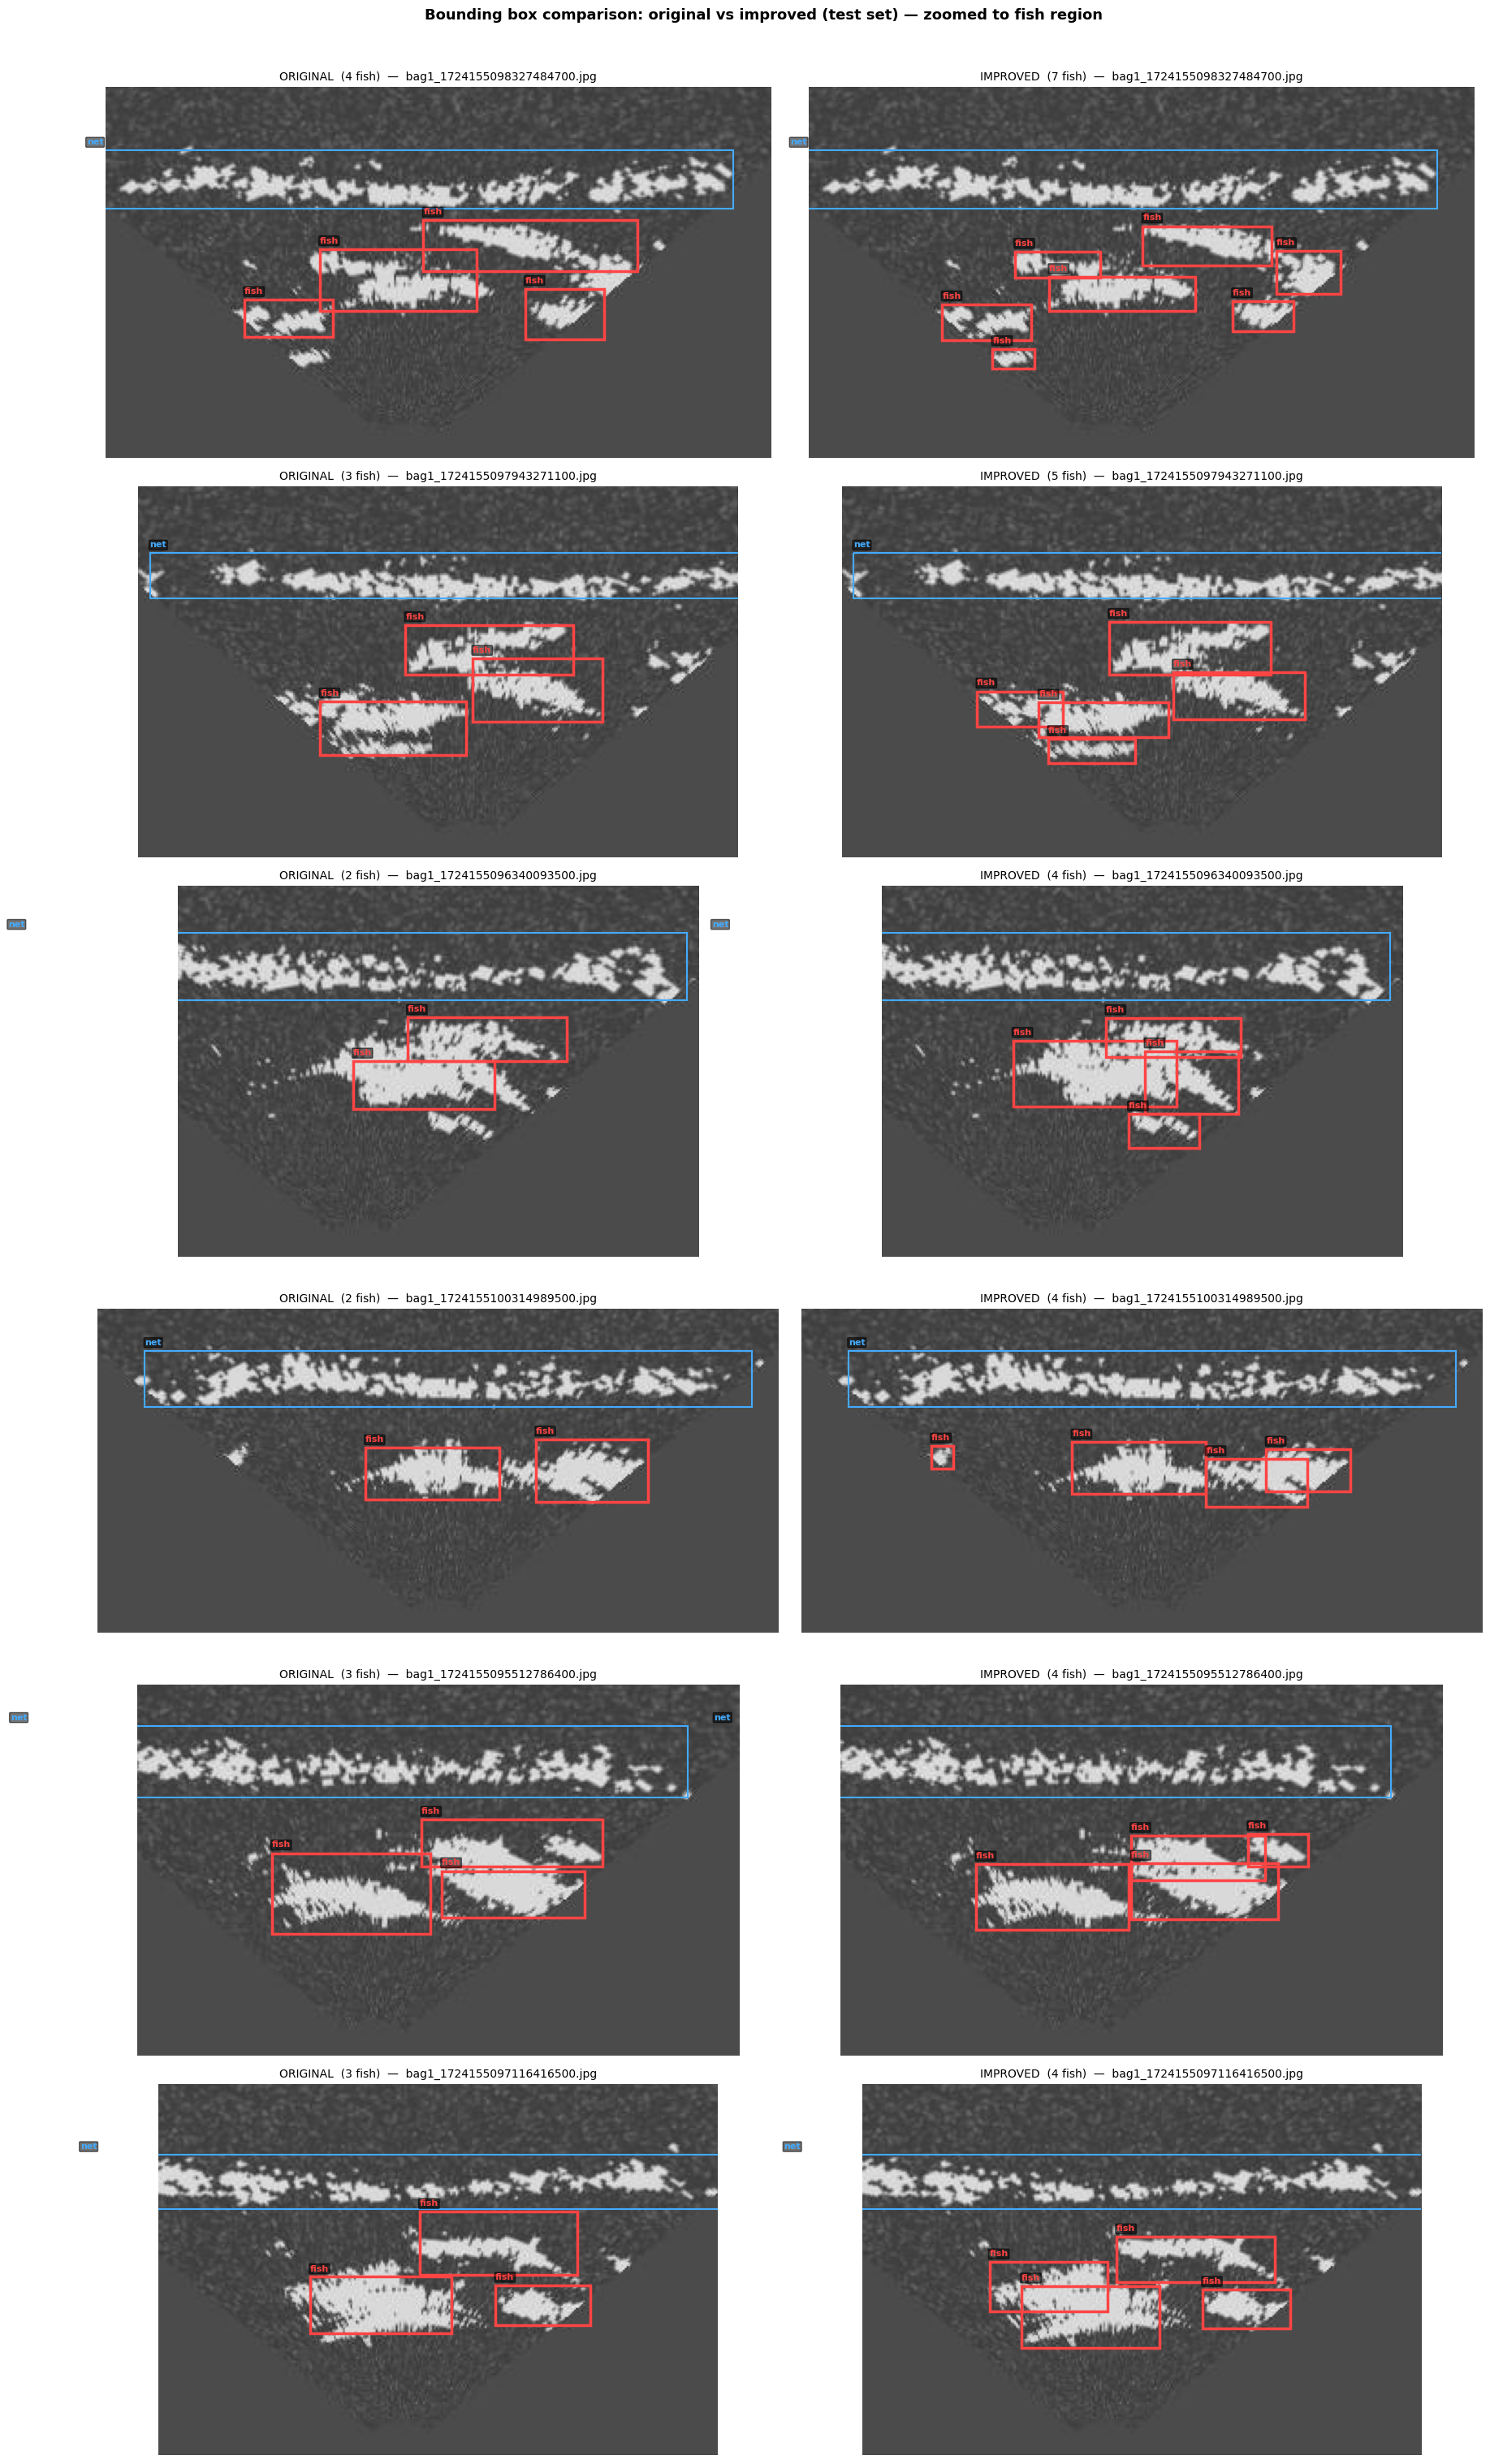

In [9]:
show_comparison(top_examples)

## 4. Summary of changes

| Aspect | Original | Improved |
|--------|----------|----------|
| **Train images** | 1,200 | 1,336 (+136) |
| **Train fish instances** | 408 | 637 (+229, +56%) |
| **Val images / fish** | 400 / 141 | 400 / 141 (unchanged) |
| **Test images** | 400 | 400 (unchanged) |
| **Test fish instances** | 144 | 165 (**+21 across 17 images**) |
| **Test BB quality** | Original annotations | Re-annotated — tighter boxes + previously missed fish added |

> **Note:** The `split_summary.csv` inside `net_fish_sonar_improved` reports 144 test fish (stale). The ground truth is the label files: **165 fish instances**.